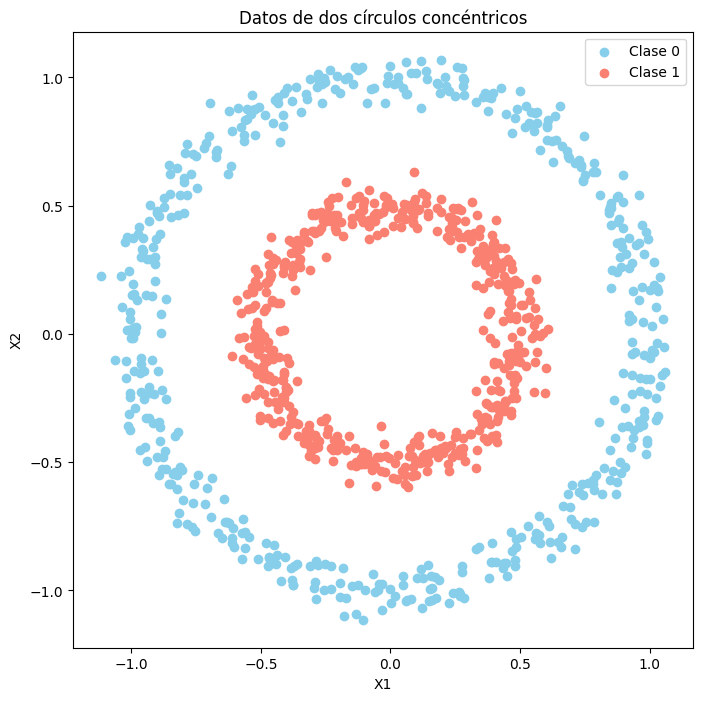

In [9]:

# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
 
# Set the seed for reproducibility
np.random.seed(42)
 
# Creamos nuestros datos artificiales (dos círculos concéntricos)
X, Y = make_circles(n_samples=1000, factor=0.5, noise=0.05)
 
# Visualización de los datos generados
plt.figure(figsize=(8, 8))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()
 
 

## Taller: clasificación de círculos concéntricos con redes neuronales profundas (Keras)

En este taller usamos una **red neuronal profunda** porque el problema de círculos concéntricos es **no linealmente separable**.

Usamos división **70% entrenamiento, 15% validación y 15% prueba** para entrenar, ajustar y evaluar de forma correcta.

In [10]:
# Preprocesamiento: división de datos y normalización

# train_test_split: permite separar el dataset en subconjuntos independientes
from sklearn.model_selection import train_test_split

# StandardScaler: normaliza características para estabilizar y acelerar el entrenamiento
from sklearn.preprocessing import StandardScaler

# Verificamos tamaño total para justificar una división robusta
print(f"Total de muestras: {len(X)}")

# 1) Separamos primero 70% entrenamiento y 30% temporal (validación + prueba)
#    Decisión: entrenamiento necesita mayoría de datos para aprender patrones complejos
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y  # Mantiene proporciones de clases en cada subconjunto
)

# 2) Del 30% temporal, tomamos mitad y mitad -> 15% validación y 15% prueba
#    Decisión: validación para ajustar arquitectura/hiperparámetros y prueba final completamente "ciega"
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Confirmamos tamaños resultantes
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X):.0%})")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X):.0%})")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X):.0%})")

# Normalización
# Decisión: aunque el rango original de make_circles ya es pequeño, normalizar ayuda a que
# las capas densas y el optimizador converjan de forma más estable y comparable entre modelos.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit solo en train para evitar fuga de información
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Total de muestras: 1000
Train: 700 (70%)
Val:   150 (15%)
Test:  150 (15%)


In [11]:
# Modelo: red neuronal profunda (múltiples capas ocultas)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fijamos semilla para reproducibilidad de resultados del entrenamiento
tf.random.set_seed(42)

# Justificación del modelo:
# Este problema (círculos concéntricos) no es linealmente separable.
# Por esa razón removemos el modelo simple lineal y usamos directamente una red profunda,
# que sí puede aprender fronteras de decisión no lineales mediante capas ocultas + activaciones.

# Decisión de arquitectura profunda:
# - Capas ocultas con activación ReLU permiten transformaciones no lineales del espacio original.
# - Más de una capa ayuda a construir fronteras de decisión complejas para separar círculos.
deep_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# Decisión de compilación:
# - binary_crossentropy: pérdida estándar para clasificación binaria
# - adam: optimizador robusto para comenzar en problemas tabulares
# - accuracy: métrica intuitiva para evaluar clasificación
deep_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# EarlyStopping:
# - Decisión: detener entrenamiento cuando ya no mejora validación
# - Beneficio: evita sobreajuste y reduce tiempo de entrenamiento
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_deep = deep_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

deep_test_loss, deep_test_acc = deep_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Modelo profundo - Test accuracy: {deep_test_acc:.4f}")

Modelo profundo - Test accuracy: 1.0000


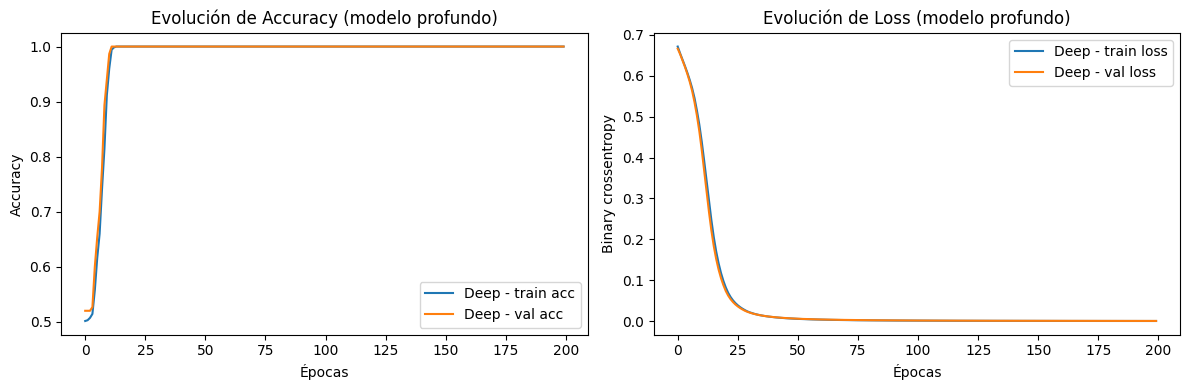


Resumen final de desempeño en test
- Modelo profundo: 1.0000


In [12]:
# Evolución de entrenamiento del modelo profundo

plt.figure(figsize=(12, 4))

# Accuracy de entrenamiento y validación
plt.subplot(1, 2, 1)
plt.plot(history_deep.history["accuracy"], label="Deep - train acc")
plt.plot(history_deep.history["val_accuracy"], label="Deep - val acc")
plt.title("Evolución de Accuracy (modelo profundo)")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

# Loss de entrenamiento y validación
plt.subplot(1, 2, 2)
plt.plot(history_deep.history["loss"], label="Deep - train loss")
plt.plot(history_deep.history["val_loss"], label="Deep - val loss")
plt.title("Evolución de Loss (modelo profundo)")
plt.xlabel("Épocas")
plt.ylabel("Binary crossentropy")
plt.legend()

plt.tight_layout()
plt.show()

print("\nResumen final de desempeño en test")
print(f"- Modelo profundo: {deep_test_acc:.4f}")

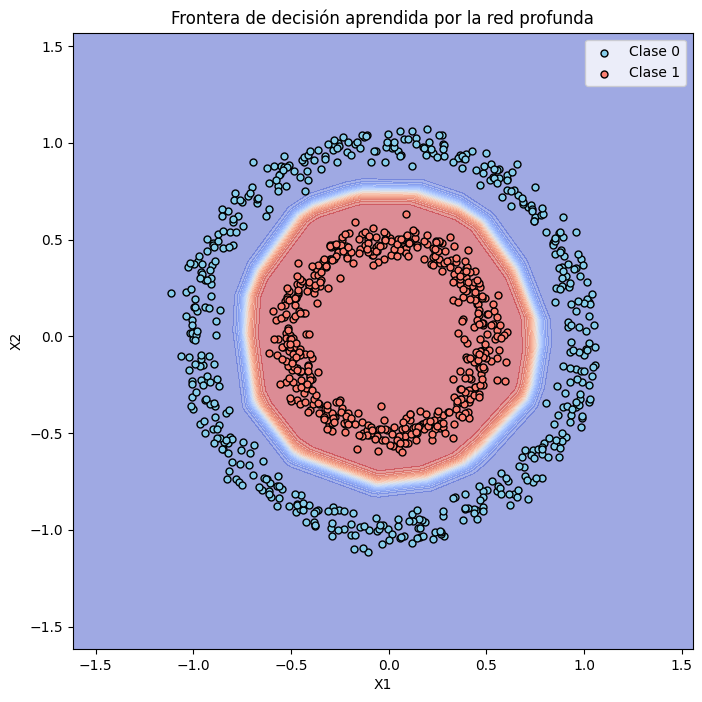

In [8]:
# Visualización de frontera de decisión del modelo profundo

# Decisión: graficar la frontera permite interpretar qué aprendió la red más allá de la métrica
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
probs = deep_model.predict(grid_scaled, verbose=0).reshape(xx.shape)

plt.figure(figsize=(8, 8))
plt.contourf(xx, yy, probs, levels=30, cmap="coolwarm", alpha=0.5)
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0", edgecolor="k", s=25)
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1", edgecolor="k", s=25)
plt.title("Frontera de decisión aprendida por la red profunda")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()